# NuScenes Setup Guide

## 1. Nuscenes v1.0-mini Dataset Download

Use the following command to download the dataset:

```bash
curl --header 'Host: d36yt3mvayqw5m.cloudfront.net' --header 'User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36' --header 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7' --header 'Accept-Language: en-US,en;q=0.9,zh-CN;q=0.8,zh;q=0.7' --header 'Referer: https://www.nuscenes.org/' 'https://d36yt3mvayqw5m.cloudfront.net/public/v1.0/v1.0-mini.tgz' -L -o 'v1.0-mini.tgz'
```

After downloading, unzip the file:

```bash
tar -xvzf v1.0-mini.tgz
```

---

## 2. Nuscenes Package Installation

Install the nuscenes-devkit package using pip:

```bash
pip install nuscenes-devkit
```

You can find the official repo here: [nuscenes-devkit](https://github.com/nutonomy/nuscenes-devkit)

---

## 3. Nuscenes Map Expansion (For Visualization)

Download the map expansion file:

```bash
curl --header 'Host: d36yt3mvayqw5m.cloudfront.net' --header 'User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36' --header 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7' --header 'Accept-Language: en-US,en;q=0.9,zh-CN;q=0.8,zh;q=0.7' --header 'Referer: https://www.nuscenes.org/' 'https://d36yt3mvayqw5m.cloudfront.net/public/v1.0/nuScenes-map-expansion-v1.3.zip' -L -o 'nuScenes-map-expansion-v1.3.zip'
```

Unzip the file:

```bash
unzip nuScenes-map-expansion-v1.3.zip
```

Then copy the `/expansion` folder and paste it to your data directory in step 1:

You will have `YOUR_DATA_ROOT/nuscenes/maps/expansion/...`

---


\* If you find the dataset is incomplete, please check official download page: [link](https://www.nuscenes.org/nuscenes#download)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion import arcline_path_utils
from nuscenes.map_expansion.bitmap import BitMap
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict


In [3]:
import os

# Initialize nuScenes dataset
dataroot = os.path.expanduser('/home/aleenatron/Frames_AV_research')
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

# Select a scene

index = 4
scene = nusc.scene[index]
first_sample_token = scene['first_sample_token']
sample = nusc.get('sample', first_sample_token)
ego_vehicle_start_time = sample['timestamp']

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.428 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [4]:
scene['description']

'Arrive at busy intersection, bus, wait at intersection, bicycle, peds'

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.343 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/home/aleenatron/.local/lib/python3.10/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


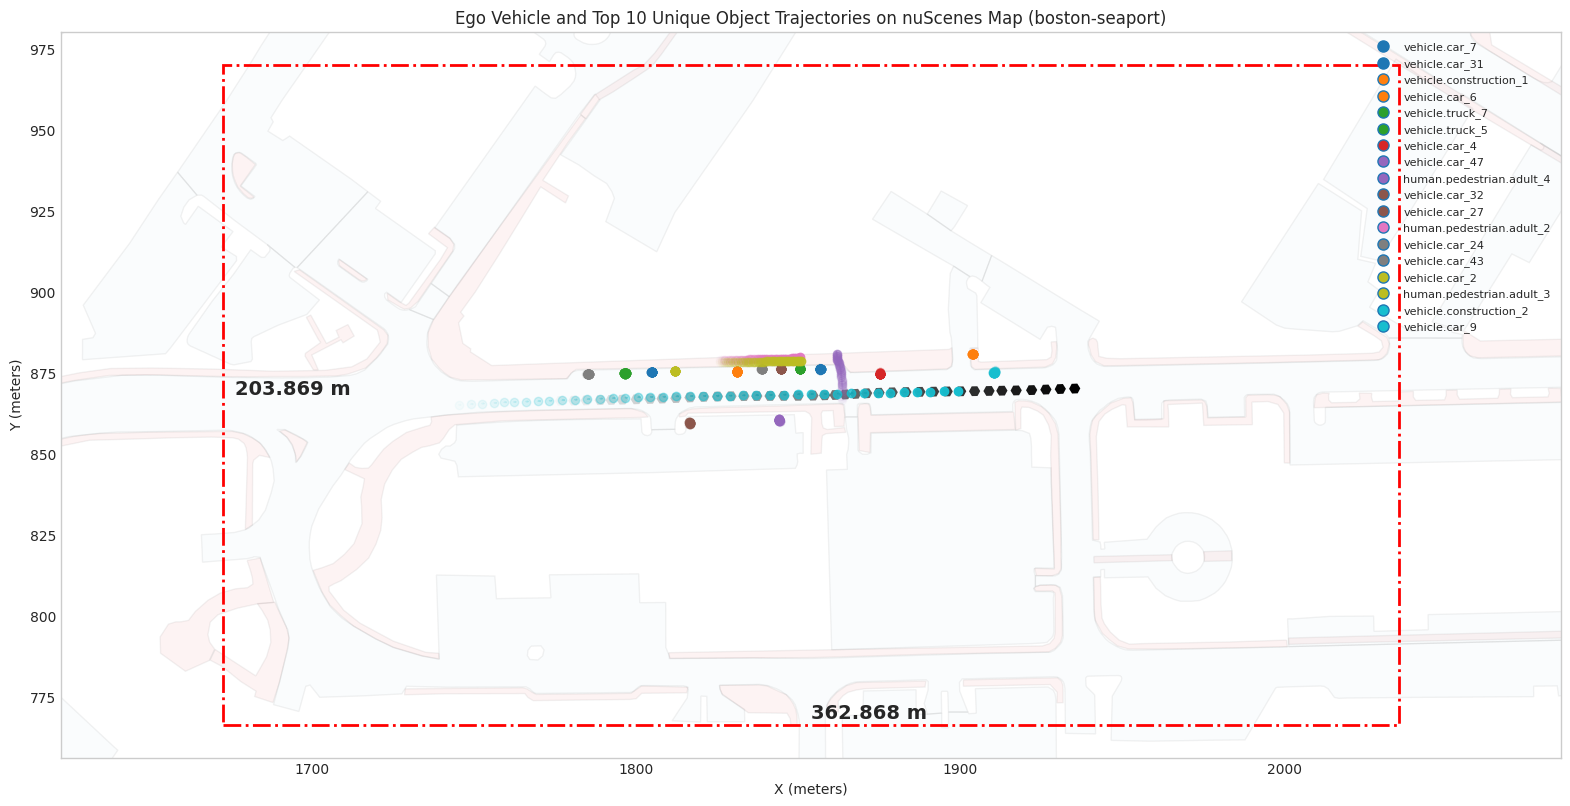

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict
from nuscenes.map_expansion.map_api import NuScenesMap

# Initialize nuScenes dataset
nusc = NuScenes(version='v1.0-mini', dataroot='/home/aleenatron/Frames_AV_research', verbose=True)

# Select a scene (forth scene)
index = 3
scene = nusc.scene[index]
first_sample_token = scene['first_sample_token']

# Get the correct map for the scene
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot='/home/aleenatron/Frames_AV_research', map_name=location)

# Store ego trajectory and object trajectories
ego_trajectory = []
ego_orientations = []
timestamps = []

object_trajectories = defaultdict(list)
object_orientations = defaultdict(list)
object_labels = {}

# Function to convert quaternion to 2D yaw angle
def quaternion_to_yaw(quaternion):
    q = Quaternion(quaternion)
    yaw = np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))
    return yaw

# Track object instances separately
object_name_counter = defaultdict(int)

# Loop through all samples in the scene
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)

    # Get timestamp (normalize between 0 and 1 for transparency)
    timestamps.append(sample['timestamp'])

    # Get ego_pose information
    sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Using LiDAR for reference
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    ego_position = tuple(ego_pose['translation'][:2])  # X, Y position
    ego_yaw = quaternion_to_yaw(ego_pose['rotation'])  # Get orientation (yaw)

    ego_trajectory.append(ego_position)
    ego_orientations.append(ego_yaw)

    # Track all objects in the scene
    for ann_token in sample['anns']:
        ann_data = nusc.get('sample_annotation', ann_token)
        instance_token = ann_data['instance_token']
        object_position = tuple(ann_data['translation'][:2])  # Convert to tuple for uniqueness
        object_yaw = quaternion_to_yaw(ann_data['rotation'])  # Get orientation (yaw)

        # Get object category name
        category_name = ann_data['category_name']
        
        # Differentiate identical objects with numbering (_1, _2, ...)
        if instance_token not in object_labels:
            object_name_counter[category_name] += 1
            unique_name = f"{category_name}_{object_name_counter[category_name]}"
            object_labels[instance_token] = unique_name

        # Store object trajectory and orientation
        object_trajectories[instance_token].append(object_position)
        object_orientations[instance_token].append(object_yaw)

    # Move to the next sample
    sample_token = sample['next']

# Normalize timestamps for transparency (0 = oldest, 1 = newest)
timestamps = np.array(timestamps)
timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())  # Normalize between 0 and 1

# Convert ego trajectory to NumPy arrays for plotting
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)

# **Count unique locations per object (at ranking stage)**
unique_location_counts = {}
filtered_trajectories = {}
filtered_orientations = {}

for instance_token, trajectory in object_trajectories.items():
    unique_locs = OrderedDict()  # Ensure order and store first occurrence of each location
    for i, loc in enumerate(trajectory):
        if loc not in unique_locs:
            unique_locs[loc] = object_orientations[instance_token][i]  # Store first orientation for each unique loc
    
    unique_location_counts[instance_token] = len(unique_locs)  # Count unique locations
    filtered_trajectories[instance_token] = list(unique_locs.keys())  # Store unique locations
    filtered_orientations[instance_token] = list(unique_locs.values())  # Store linked orientations

# **Sort and filter the top 10 longest unique-location trajectories (including ties)**
sorted_lengths = sorted(set(unique_location_counts.values()), reverse=True)  # Get unique lengths, sorted descending

# Keep all objects with trajectory length in the top 10 unique values
if len(sorted_lengths) > 10:
    threshold_length = sorted_lengths[9]  # Get the 10th longest unique length
    selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold_length}
else:
    selected_instances = set(unique_location_counts.keys())  # If fewer than 10 unique lengths, plot all

# Generate distinct colors for selected instances
color_map = cm.get_cmap("tab10", len(selected_instances))
instance_colors = {inst: color_map(i) for i, inst in enumerate(selected_instances)}

# Determine the bounding box for the map (x_min, y_min, x_max, y_max)
x_min, y_min = np.min(ego_trajectory, axis=0) - 100  # Expand by 50m buffer
x_max, y_max = np.max(ego_trajectory, axis=0) + 100  # Expand by 50m buffer
map_bounds = (x_min, y_min, x_max, y_max)

# Define the layer names to be rendered
layer_names = ['drivable_area', 'walkway']

# Render the map patch with 50% transparency
fig, ax = nusc_map.render_map_patch(map_bounds, layer_names, alpha=0.05)

# **Ensure the same distance scale for x and y**
ax.set_aspect('equal')
# Store legend labels
legend_labels = {}

# Plot only the selected top 10 objects with unique colors
# **Apply transparency correctly to instance trajectories**
for instance_token in selected_instances:
    trajectory = np.array(filtered_trajectories[instance_token])
    orientations = np.array(filtered_orientations[instance_token])
    object_name = object_labels[instance_token]
    obj_color = instance_colors[instance_token]

    legend_labels[object_name] = obj_color[:3]  # Store the object name and color for the legend

    for i in range(len(trajectory)):
        alpha = timestamps[i]  # Ensure timestamps are mapped correctly for transparency
        ax.plot(trajectory[i, 0], trajectory[i, 1], marker='o', color=(*obj_color[:3], alpha))  # Correct transparency
        ax.arrow(trajectory[i, 0], trajectory[i, 1],
                 0.5 * np.cos(orientations[i]), 0.5 * np.sin(orientations[i]),
                 head_width=0.3, head_length=0.3, fc=(*obj_color[:3], alpha), ec=(*obj_color[:3], alpha))

# Plot ego trajectory with transparency
for i in range(len(ego_trajectory)):
    alpha = timestamps[i]
        
    dx = 3 * np.cos(ego_orientations[i])
    dy = 3 * np.sin(ego_orientations[i])
    ax.quiver(ego_trajectory[i, 0], ego_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(0,0,0,alpha))



# Create legend for instances
legend_entries = [plt.Line2D([0], [0], marker='o', markerfacecolor=color, markersize=8, linestyle='None', label=name)
                  for name, color in legend_labels.items()]

# Combine both legends
combined_legend = legend_entries
# Labels and title
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Ego Vehicle and Top 10 Unique Object Trajectories on nuScenes Map ({location})")

# Labels and title
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Ego Vehicle and Top 10 Unique Object Trajectories on nuScenes Map ({location})")
plt.legend(handles=combined_legend, loc='upper right', fontsize=8)  # Keep both legends
plt.grid()
plt.show()

In [7]:
# %matplotlib ipympl
%matplotlib widget
# %matplotlib notebook

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.401 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


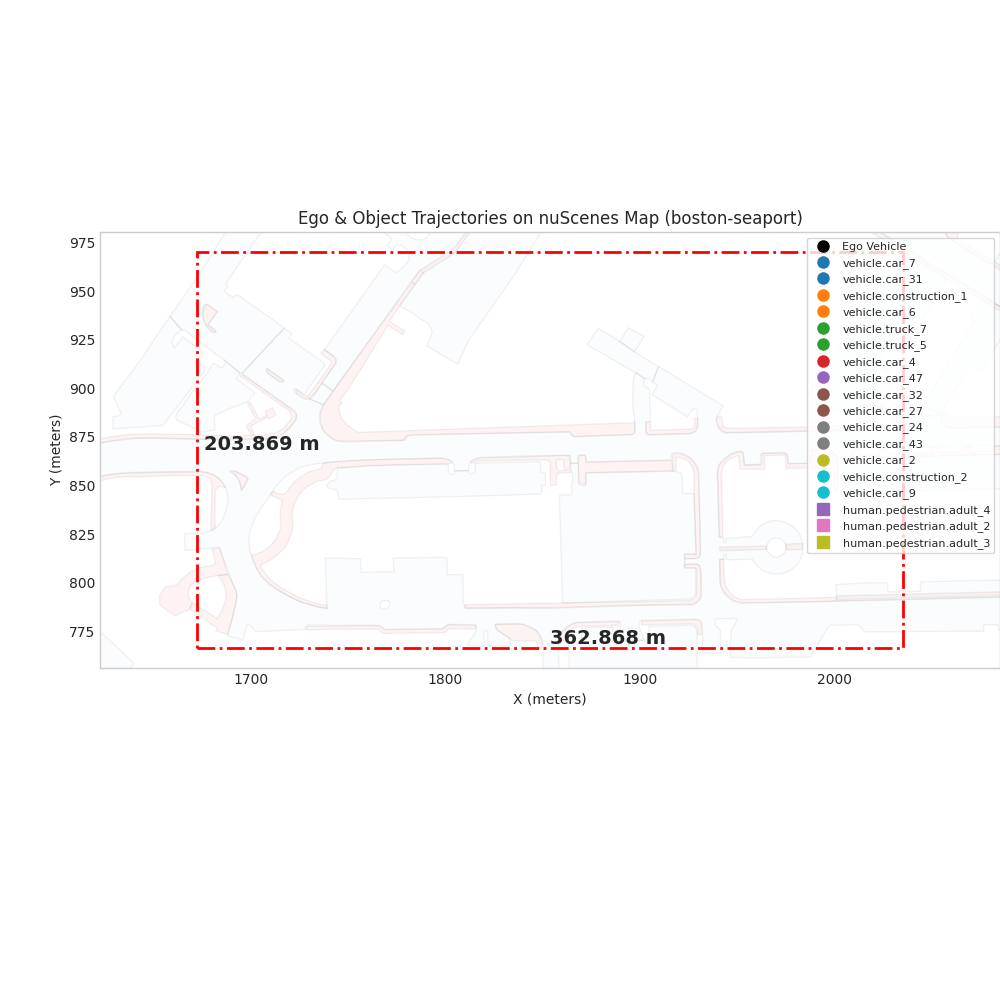

In [10]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict
from nuscenes.map_expansion.map_api import NuScenesMap

# === Dataset setup ===
nusc = NuScenes(version='v1.0-mini', dataroot='/home/aleenatron/Frames_AV_research', verbose=True)
scene = nusc.scene[index]
first_sample_token = scene['first_sample_token']
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot='/home/aleenatron/Frames_AV_research', map_name=location)

# === Marker style by category root ===
category_marker_map = {
    'vehicle': 'o',
    'human': 's',
    'movable_object': '^',
    'animal': 'D',
    'static_object': 'x',
    'flat': 'P'
}

# === Containers ===
ego_trajectory, ego_orientations, timestamps = [], [], []
object_trajectories, object_orientations = defaultdict(list), defaultdict(list)
object_labels = {}
object_name_counter = defaultdict(int)
object_category_root = {}

def quaternion_to_yaw(q):
    q = Quaternion(q)
    return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y**2 + q.z**2))

# === Loop through frames ===
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)
    timestamps.append(sample['timestamp'])

    ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
    ego_trajectory.append(tuple(ego_pose['translation'][:2]))
    ego_orientations.append(quaternion_to_yaw(ego_pose['rotation']))

    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        inst = ann['instance_token']
        category = ann['category_name']
        root = category.split('.')[0]
        object_category_root[inst] = root

        if inst not in object_labels:
            object_name_counter[category] += 1
            object_labels[inst] = f"{category}_{object_name_counter[category]}"

        object_trajectories[inst].append(tuple(ann['translation'][:2]))
        object_orientations[inst].append(quaternion_to_yaw(ann['rotation']))
    sample_token = sample['next']

# === Normalize & Filter ===
timestamps = np.array(timestamps)
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)

unique_location_counts = {
    k: len(set(object_trajectories[k])) for k in object_trajectories
}
sorted_lens = sorted(set(unique_location_counts.values()), reverse=True)
threshold = sorted_lens[9] if len(sorted_lens) > 10 else 0
selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold}

# === Color map ===
color_map = cm.get_cmap("tab10", len(selected_instances))
instance_colors = {inst: color_map(i) for i, inst in enumerate(selected_instances)}

# === Set up map plot ===
x_min, y_min = ego_trajectory.min(axis=0) - 100
x_max, y_max = ego_trajectory.max(axis=0) + 100
fig, ax = nusc_map.render_map_patch((x_min, y_min, x_max, y_max), ['drivable_area', 'walkway'], alpha=0.05)
fig.set_size_inches(10, 10)
ax.set_aspect('equal')

# Set tight bounding box for the Axes object (not just subplots)
ax.set_position([0.1, 0.1, 0.9, 0.9])  # [left, bottom, width, height] in figure coords

# === Ego ===
ego_dot, = ax.plot([], [], 'o', color='black', markersize=6)
ego_arrow = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color='black')

# === Object dots & legend entries ===
obj_dots = {}
grouped_legend = defaultdict(list)

for i, inst in enumerate(selected_instances):
    category = object_category_root[inst]
    marker = category_marker_map.get(category, 'o')
    color = instance_colors[inst]
    label = object_labels[inst]
    
    dot, = ax.plot([], [], marker=marker, linestyle='None', color=color, markersize=6)
    obj_dots[inst] = dot

    legend_entry = plt.Line2D([0], [0], marker=marker, color=color, linestyle='None', markersize=8, label=label)
    grouped_legend[category].append(legend_entry)

# === Animation functions ===
def init():
    ego_dot.set_data([], [])
    ego_arrow.set_offsets([0, 0])
    ego_arrow.set_UVC(0, 0)
    for dot in obj_dots.values():
        dot.set_data([], [])
    return [ego_dot, ego_arrow] + list(obj_dots.values())

def update(frame):
    x, y = ego_trajectory[frame]
    yaw = ego_orientations[frame]
    ego_dot.set_data(x, y)
    ego_arrow.set_offsets([x, y])
    ego_arrow.set_UVC(3 * np.cos(yaw), 3 * np.sin(yaw))
    for inst in selected_instances:
        traj = object_trajectories[inst]
        if frame < len(traj):
            px, py = traj[frame]
            obj_dots[inst].set_data(px, py)
    return [ego_dot, ego_arrow] + list(obj_dots.values())

ani = animation.FuncAnimation(fig, update, init_func=init,
                              frames=len(timestamps), interval=300, blit=False)

# === Grouped Legend ===
category_order = ['vehicle', 'movable_object', 'human', 'animal', 'static_object', 'flat']
legend_entries = [plt.Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=8, label='Ego Vehicle')]

for cat in category_order:
    if cat in grouped_legend:
        legend_entries.extend(grouped_legend[cat])

ax.legend(handles=legend_entries, loc='upper right', fontsize=8, frameon=True)
plt.title(f"Ego & Object Trajectories on nuScenes Map ({location})")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.grid()
plt.show()

In [21]:
ani.save(f"./nuscenes_animation_scene_{index}.gif", writer='pillow', fps=5)

In [ ]:
# save 10 animations
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict
from nuscenes.map_expansion.map_api import NuScenesMap

for index in range(10):



    # === Dataset setup ===
    nusc = NuScenes(version='v1.0-mini', dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', verbose=True)
    scene = nusc.scene[index]
    first_sample_token = scene['first_sample_token']
    log = nusc.get("log", scene["log_token"])
    location = log["location"]
    nusc_map = NuScenesMap(dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', map_name=location)

    # === Marker style by category root ===
    category_marker_map = {
        'vehicle': 'o',
        'human': 's',
        'movable_object': '^',
        'animal': 'D',
        'static_object': 'x',
        'flat': 'P'
    }

    # === Containers ===
    ego_trajectory, ego_orientations, timestamps = [], [], []
    object_trajectories, object_orientations = defaultdict(list), defaultdict(list)
    object_labels = {}
    object_name_counter = defaultdict(int)
    object_category_root = {}

    def quaternion_to_yaw(q):
        q = Quaternion(q)
        return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y**2 + q.z**2))

    # === Loop through frames ===
    sample_token = first_sample_token
    while sample_token:
        sample = nusc.get('sample', sample_token)
        timestamps.append(sample['timestamp'])

        ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
        ego_trajectory.append(tuple(ego_pose['translation'][:2]))
        ego_orientations.append(quaternion_to_yaw(ego_pose['rotation']))

        for ann_token in sample['anns']:
            ann = nusc.get('sample_annotation', ann_token)
            inst = ann['instance_token']
            category = ann['category_name']
            root = category.split('.')[0]
            object_category_root[inst] = root

            if inst not in object_labels:
                object_name_counter[category] += 1
                object_labels[inst] = f"{category}_{object_name_counter[category]}"

            object_trajectories[inst].append(tuple(ann['translation'][:2]))
            object_orientations[inst].append(quaternion_to_yaw(ann['rotation']))
        sample_token = sample['next']

    # === Normalize & Filter ===
    timestamps = np.array(timestamps)
    ego_trajectory = np.array(ego_trajectory)
    ego_orientations = np.array(ego_orientations)

    unique_location_counts = {
        k: len(set(object_trajectories[k])) for k in object_trajectories
    }
    sorted_lens = sorted(set(unique_location_counts.values()), reverse=True)
    threshold = sorted_lens[9] if len(sorted_lens) > 10 else 0
    selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold}

    # === Color map ===
    color_map = cm.get_cmap("tab10", len(selected_instances))
    instance_colors = {inst: color_map(i) for i, inst in enumerate(selected_instances)}

    # === Set up map plot ===
    x_min, y_min = ego_trajectory.min(axis=0) - 100
    x_max, y_max = ego_trajectory.max(axis=0) + 100
    fig, ax = nusc_map.render_map_patch((x_min, y_min, x_max, y_max), ['drivable_area', 'walkway'], alpha=0.05)
    fig.set_size_inches(10, 10)
    ax.set_aspect('equal')

    # Set tight bounding box for the Axes object (not just subplots)
    ax.set_position([0.1, 0.1, 0.8, 0.8])  # [left, bottom, width, height] in figure coords

    # === Ego ===
    ego_dot, = ax.plot([], [], 'o', color='black', markersize=6)
    ego_arrow = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color='black')

    # === Object dots & legend entries ===
    obj_dots = {}
    grouped_legend = defaultdict(list)

    for i, inst in enumerate(selected_instances):
        category = object_category_root[inst]
        marker = category_marker_map.get(category, 'o')
        color = instance_colors[inst]
        label = object_labels[inst]

        dot, = ax.plot([], [], marker=marker, linestyle='None', color=color, markersize=6)
        obj_dots[inst] = dot

        legend_entry = plt.Line2D([0], [0], marker=marker, color=color, linestyle='None', markersize=8, label=label)
        grouped_legend[category].append(legend_entry)

    # === Animation functions ===
    def init():
        ego_dot.set_data([], [])
        ego_arrow.set_offsets([0, 0])
        ego_arrow.set_UVC(0, 0)
        for dot in obj_dots.values():
            dot.set_data([], [])
        return [ego_dot, ego_arrow] + list(obj_dots.values())

    def update(frame):
        x, y = ego_trajectory[frame]
        yaw = ego_orientations[frame]
        ego_dot.set_data(x, y)
        ego_arrow.set_offsets([x, y])
        ego_arrow.set_UVC(3 * np.cos(yaw), 3 * np.sin(yaw))
        for inst in selected_instances:
            traj = object_trajectories[inst]
            if frame < len(traj):
                px, py = traj[frame]
                obj_dots[inst].set_data(px, py)
        return [ego_dot, ego_arrow] + list(obj_dots.values())

    ani = animation.FuncAnimation(fig, update, init_func=init,
                                  frames=len(timestamps), interval=300, blit=False)

    # === Grouped Legend ===
    category_order = ['vehicle', 'movable_object', 'human', 'animal', 'static_object', 'flat']
    legend_entries = [plt.Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=8, label='Ego Vehicle')]

    for cat in category_order:
        if cat in grouped_legend:
            legend_entries.extend(grouped_legend[cat])

    ax.legend(handles=legend_entries, loc='upper right', fontsize=8, frameon=True)
    plt.title(f"Ego & Object Trajectories on nuScenes Map ({location})")
    plt.xlabel("X (meters)")
    plt.ylabel("Y (meters)")
    plt.grid()
    plt.show()
    ani.save(f"./nuscenes_animation_scene_{index}.gif", writer='pillow', fps=5)

In [38]:
for index in range(10):
    scene = nusc.scene[index]
    print(scene['description'])

Parked truck, construction, intersection, turn left, following a van
Many peds right, wait for turning car, long bike rack left, cyclist
Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller
Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles
Arrive at busy intersection, bus, wait at intersection, bicycle, peds
Scooter, peds on sidewalk, bus, cars, truck, fake construction worker, bicycle, cross intersection, car overtaking us
Parking lot, bicycle rack, parked bicycles, bus, many peds, parked scooters, parked motorcycle
Night, big street, bus stop, high speed, construction vehicle
Night, after rain, many peds, PMD, ped with bag, jaywalker, truck, scooter
Night, peds in sidewalk, peds cross crosswalk, scooter, PMD, difficult lighting


In [39]:
print(nusc.scene[3]['description'])

Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.178 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


/opt/anaconda3/envs/nuscenes/lib/python3.9/site-packages/matplotlib/animation.py:887: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you have outputted the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


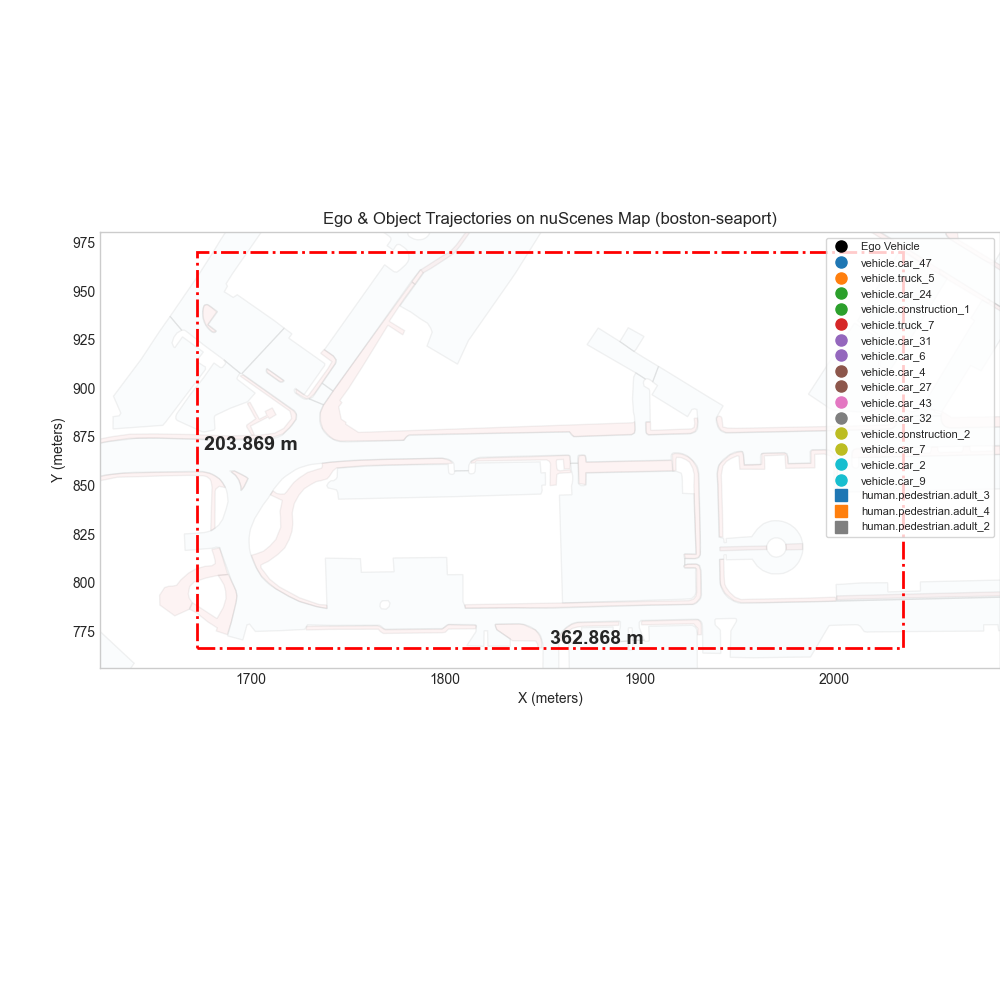

In [2]:
# %matplotlib ipympl
%matplotlib widget
# %matplotlib notebook


index = 3


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict
from nuscenes.map_expansion.map_api import NuScenesMap

# === Dataset setup ===
nusc = NuScenes(version='v1.0-mini', dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', verbose=True)
scene = nusc.scene[index]
first_sample_token = scene['first_sample_token']
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', map_name=location)

# === Marker style by category root ===
category_marker_map = {
    'vehicle': 'o',
    'human': 's',
    'movable_object': '^',
    'animal': 'D',
    'static_object': 'x',
    'flat': 'P'
}

# === Containers ===
ego_trajectory, ego_orientations, timestamps = [], [], []
object_trajectories, object_orientations = defaultdict(list), defaultdict(list)
object_labels = {}
object_name_counter = defaultdict(int)
object_category_root = {}

def quaternion_to_yaw(q):
    q = Quaternion(q)
    return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y**2 + q.z**2))

# === Loop through frames ===
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)
    timestamps.append(sample['timestamp'])

    ego_pose = nusc.get('ego_pose', nusc.get('sample_data', sample['data']['LIDAR_TOP'])['ego_pose_token'])
    ego_trajectory.append(tuple(ego_pose['translation'][:2]))
    ego_orientations.append(quaternion_to_yaw(ego_pose['rotation']))

    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        inst = ann['instance_token']
        category = ann['category_name']
        root = category.split('.')[0]
        object_category_root[inst] = root

        if inst not in object_labels:
            object_name_counter[category] += 1
            object_labels[inst] = f"{category}_{object_name_counter[category]}"

        object_trajectories[inst].append(tuple(ann['translation'][:2]))
        object_orientations[inst].append(quaternion_to_yaw(ann['rotation']))
    sample_token = sample['next']

# === Normalize & Filter ===
timestamps = np.array(timestamps)
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)

unique_location_counts = {
    k: len(set(object_trajectories[k])) for k in object_trajectories
}
sorted_lens = sorted(set(unique_location_counts.values()), reverse=True)
threshold = sorted_lens[9] if len(sorted_lens) > 10 else 0
selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold}

# === Color map ===
color_map = cm.get_cmap("tab10", len(selected_instances))
instance_colors = {inst: color_map(i) for i, inst in enumerate(selected_instances)}

# === Set up map plot ===
x_min, y_min = ego_trajectory.min(axis=0) - 100
x_max, y_max = ego_trajectory.max(axis=0) + 100
fig, ax = nusc_map.render_map_patch((x_min, y_min, x_max, y_max), ['drivable_area', 'walkway'], alpha=0.05)
fig.set_size_inches(10, 10)
ax.set_aspect('equal')

# Set tight bounding box for the Axes object (not just subplots)
ax.set_position([0.1, 0.1, 0.9, 0.9])  # [left, bottom, width, height] in figure coords

# === Ego ===
ego_dot, = ax.plot([], [], 'o', color='black', markersize=6)
ego_arrow = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color='black')

# === Object dots & legend entries ===
obj_dots = {}
grouped_legend = defaultdict(list)

for i, inst in enumerate(selected_instances):
    category = object_category_root[inst]
    marker = category_marker_map.get(category, 'o')
    color = instance_colors[inst]
    label = object_labels[inst]
    
    dot, = ax.plot([], [], marker=marker, linestyle='None', color=color, markersize=6)
    obj_dots[inst] = dot

    legend_entry = plt.Line2D([0], [0], marker=marker, color=color, linestyle='None', markersize=8, label=label)
    grouped_legend[category].append(legend_entry)

# === Animation functions ===
def init():
    ego_dot.set_data([], [])
    ego_arrow.set_offsets([0, 0])
    ego_arrow.set_UVC(0, 0)
    for dot in obj_dots.values():
        dot.set_data([], [])
    return [ego_dot, ego_arrow] + list(obj_dots.values())

def update(frame):
    x, y = ego_trajectory[frame]
    yaw = ego_orientations[frame]
    ego_dot.set_data(x, y)
    ego_arrow.set_offsets([x, y])
    ego_arrow.set_UVC(3 * np.cos(yaw), 3 * np.sin(yaw))
    for inst in selected_instances:
        traj = object_trajectories[inst]
        if frame < len(traj):
            px, py = traj[frame]
            obj_dots[inst].set_data(px, py)
    return [ego_dot, ego_arrow] + list(obj_dots.values())

ani = animation.FuncAnimation(fig, update, init_func=init,
                              frames=len(timestamps), interval=300, blit=False)

# === Grouped Legend ===
category_order = ['vehicle', 'movable_object', 'human', 'animal', 'static_object', 'flat']
legend_entries = [plt.Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=8, label='Ego Vehicle')]

for cat in category_order:
    if cat in grouped_legend:
        legend_entries.extend(grouped_legend[cat])

ax.legend(handles=legend_entries, loc='upper right', fontsize=8, frameon=True)
plt.title(f"Ego & Object Trajectories on nuScenes Map ({location})")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.grid()
plt.show()

# Get the description from our Frames

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion import arcline_path_utils
from nuscenes.map_expansion.bitmap import BitMap
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict


In [6]:
from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion
import os
from nuscenes.nuscenes import NuScenes


# Precompute ego vehicle positions
def compute_scene_ego_positions(nusc, scene_index):
    scene_ego_positions = {}
    scene = nusc.scene[scene_index]
    first_sample_token = scene['first_sample_token']
    first_sample = nusc.get('sample', first_sample_token)
    ego_vehicle_raw_start_time = first_sample['timestamp'] / 1e6

    sample_token = first_sample_token
    while sample_token:
        sample = nusc.get('sample', sample_token)
        timestamp = sample['timestamp'] / 1e6
        sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
        scene_ego_positions[timestamp] = tuple(ego_pose['translation'][:2])
        sample_token = sample['next']

    return scene_ego_positions, ego_vehicle_raw_start_time

class InstanceFrame:
    """ Class to store and process instance frame information from nuScenes dataset. """
    
    def __init__(self, nusc, instance_token, scene_index, scene_ego_positions, ego_vehicle_raw_start_time):
        """
        Initializes an InstanceFrame object and extracts relevant data.

        Args:
            nusc: NuScenes database instance.
            instance_token: The token of the instance to extract.
            scene_index: The index of the scene in nuScenes dataset.
            scene_ego_positions: Precomputed ego vehicle positions for this scene.
            ego_vehicle_raw_start_time: The raw start timestamp of the ego vehicle (in seconds).
        """
        self.nusc = nusc
        self.instance_token = instance_token
        self.scene_index = scene_index
        self.scene_ego_positions = scene_ego_positions
        self.ego_vehicle_raw_start_time = ego_vehicle_raw_start_time

        # Core attributes
        self.category_name = None
        self.instance_name = None
        self.start_time = None
        self.end_time = None
        self.duration = None
        self.raw_start_time = None
        self.raw_end_time = None
        self.locations = []
        self.orientations = []
        self.sample_tokens = []
        self.scene_token = None

        # Extract information
        self._extract_instance_data()
        self._normalize_times()

    def _extract_instance_data(self):
        """ Extract structured Frame representation for the instance in nuScenes. """

        instance = self.nusc.get('instance', self.instance_token)
        first_ann_token = instance['first_annotation_token']
        
        ann = self.nusc.get('sample_annotation', first_ann_token)
        self.category_name = ann['category_name']

        while ann:
            sample = self.nusc.get('sample', ann['sample_token'])
            timestamp = sample['timestamp'] / 1e6  # Convert to seconds

            if self.start_time is None:
                self.start_time = timestamp
                self.raw_start_time = timestamp
                self.scene_token = sample["scene_token"]

            self.end_time = timestamp
            self.raw_end_time = timestamp

            # Transform annotation from global frame to LiDAR frame
            lidar_translation, lidar_rotation = self._get_lidar_pose(sample['data']['LIDAR_TOP'])
            obj_translation = np.array(ann["translation"])
            obj_rotation = Quaternion(ann["rotation"])

            transformed_translation, transformed_yaw = self._transform_global_to_lidar(
                obj_translation, obj_rotation, lidar_translation, lidar_rotation
            )

            self.locations.append(transformed_translation[:2])  # X, Y in LiDAR frame
            self.orientations.append(transformed_yaw)  # Yaw in LiDAR frame

            self.sample_tokens.append(ann["sample_token"])

            if ann["next"]:
                ann = self.nusc.get("sample_annotation", ann["next"])
            else:
                break

        self.duration = self.end_time - self.start_time

    def _normalize_times(self):
        """ Normalize start and end times relative to the ego vehicle's first timestamp in the scene. """
        self.start_time -= self.ego_vehicle_raw_start_time
        self.end_time -= self.ego_vehicle_raw_start_time

    def _get_lidar_pose(self, lidar_token):
        """ Retrieve the LiDAR position and rotation from ego pose. """
        lidar_data = self.nusc.get('sample_data', lidar_token)
        ego_pose = self.nusc.get('ego_pose', lidar_data['ego_pose_token'])
        return np.array(ego_pose['translation']), Quaternion(ego_pose['rotation'])

    def _transform_global_to_lidar(self, obj_translation, obj_rotation, lidar_translation, lidar_rotation):
        """
        Transform object position and orientation from global frame to the LiDAR frame.
        """
    

    
        # Step 1: Translate to LiDAR's origin
        relative_translation = obj_translation - lidar_translation

    
        # Step 2: Rotate using inverse of LiDAR rotation
        transformed_translation = lidar_rotation.inverse.rotate(relative_translation)
        
        # **Fix the Axis Swapping Issue**
        transformed_translation = np.array([-transformed_translation[1], transformed_translation[0], transformed_translation[2]])
        

        # Step 3: Convert rotation to LiDAR's frame

        transformed_rotation = lidar_rotation.inverse * obj_rotation
        transformed_yaw = np.arctan2(
            2.0 * (transformed_rotation.w * transformed_rotation.z + transformed_rotation.x * transformed_rotation.y),
            1.0 - 2.0 * (transformed_rotation.y**2 + transformed_rotation.z**2)
        )
    

        # Choose whether debug with print
        if print_debug:
            print(f" LiDAR Position: {obj_rotation}")           
            print(f" Global Position: {obj_translation}")
            print(f" LiDAR Position: {lidar_translation}")
            print(f" Relative Position (before rotation): {relative_translation}")
            print(f"✅ Fixed Transformed Position (LiDAR Frame): {transformed_translation}")
            print(f" Original Rotation (Quaternion): {obj_rotation}")
            print(f"✅ Transformed Yaw (LiDAR Frame): {np.degrees(transformed_yaw)} degrees")
    
        return transformed_translation, transformed_yaw


    def _classify_orientation(self, yaw_rad):
        """ Classify the relative orientation in LiDAR frame. """
        yaw_deg = np.degrees(yaw_rad) % 360
        if yaw_deg > 180:
            yaw_deg -= 360  # Normalize to [-180, 180]

        if abs(yaw_deg) < 45:
            return "facing same direction"
        elif abs(yaw_deg - 180) < 45 or abs(yaw_deg + 180) < 45:
            return "facing opposite direction"
        elif 45 <= yaw_deg <= 135:
            return "facing leftward (perpendicular)"
        elif -135 <= yaw_deg <= -45:
            return "facing rightward (perpendicular)"
        else:
            return "heading unclear"



    def describe_movement(self):
        """
        A detailed scenario-based & dominant-direction movement description
        in LiDAR frame (x=right, y=up), considering the **entire trajectory**.
    
        Key features:
        - Describes movement trends over time.
        - Separates Left/Right and Forward/Backward positioning (no center state).
        - Tracks relative positioning with respect to the ego vehicle.
        - Detects crossing events (left↔right, behind↔ahead).
        - Computes movement dominance dynamically.
        - Reports mean and minimum distance to the ego vehicle.
    
        The 'one region' logic: explicitly says "always left/right" or "always behind/ahead"
        if applicable.



        TODO: 
              1. We take the relative distances as the trajectory distance (which might not be the same as the actual path length, according to the ego vehicle).
        """
    
        if len(self.locations) < 2:
            return "Not enough data to describe movement."
    
        distances_to_ego = [np.linalg.norm(loc) for loc in self.locations]
        mean_distance = np.mean(distances_to_ego)
        min_distance = np.min(distances_to_ego)

        movement_segments = []
        heading_segments = []
        segment_changes_lr = []
        segment_changes_fb = []
        relative_lr = []
        relative_fb = []
        total_distance = 0

        prev_x, prev_y = self.locations[0]

        for i in range(1, len(self.locations)):
            cur_x, cur_y = self.locations[i]
            dx, dy = cur_x - prev_x, cur_y - prev_y
            distance = np.hypot(dx, dy)
            total_distance += distance

            # --- Movement direction ---
            if distance < 0.5:
                move_desc = "had minor movement"
            else:
                abs_dx, abs_dy = abs(dx), abs(dy)
                ratio = abs_dx / abs_dy if abs_dy > 1e-6 else float('inf')
                if ratio > 1.5:
                    move_desc = "moved dominantly right" if dx > 0 else "moved dominantly left"
                elif ratio < 0.66:
                    move_desc = "moved dominantly forward" if dy > 0 else "moved dominantly backward"
                else:
                    move_desc = "moved diagonally"
            movement_segments.append(move_desc)

            # --- Orientation status ---
            heading_segments.append(self._classify_orientation(self.orientations[i]))

            # --- Relative lateral / longitudinal position ---
            cur_lr = "left" if cur_x < 0 else "right"
            cur_fb = "behind" if cur_y < 0 else "ahead"

            if i > 1:
                prev_lr, prev_fb = relative_lr[-1], relative_fb[-1]
                if prev_lr != cur_lr:
                    segment_changes_lr.append(f"crossed from {prev_lr} to {cur_lr}")
                if prev_fb != cur_fb:
                    segment_changes_fb.append(f"crossed from {prev_fb} to {cur_fb}")

            relative_lr.append(cur_lr)
            relative_fb.append(cur_fb)

            prev_x, prev_y = cur_x, cur_y

        movement_trend = ", then ".join(dict.fromkeys(movement_segments))
        heading_trend = ", then ".join(dict.fromkeys(heading_segments))

        # Position summaries
        lr_summary = (
            f"always {relative_lr[0]}" if len(set(relative_lr)) == 1 else
            ", ".join(dict.fromkeys(segment_changes_lr)) if segment_changes_lr else
            "exhibited partial left/right shifts"
        )
        fb_summary = (
            f"always {relative_fb[0]}" if len(set(relative_fb)) == 1 else
            ", ".join(dict.fromkeys(segment_changes_fb)) if segment_changes_fb else
            "exhibited partial forward/back shifts"
        )

        return (
            f"A {self.category_name} {movement_trend}. "
            f"Relative to the ego vehicle, it was {lr_summary} laterally "
            f"and {fb_summary} longitudinally. "
            f"It covered a total distance of approximately {total_distance:.2f}m over {self.duration:.2f}s. "
            f"Mean distance: {mean_distance:.2f}m, closest approach: {min_distance:.2f}m. "
            f"Its orientation over time was: {heading_trend}."
        )





    def to_dict(self):
        """ Converts the instance frame object to a dictionary for easy usage. """
        return {
            "instance_token": self.instance_token,
            "category_name": self.category_name,
            "instance_name": self.instance_name,
            "raw_start_time": self.raw_start_time,
            "raw_end_time": self.raw_end_time,
            "ego_vehicle_raw_start_time": self.ego_vehicle_raw_start_time,
            "start_time": self.start_time,
            "end_time": self.end_time,
            "duration": self.duration,
            "locations": self.locations,
            "orientations": self.orientations,
            "sample_tokens": self.sample_tokens,
            "scene_token": self.scene_token,
            "description": self.describe_movement()
        }

# Example usage:
# scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
# instance_frame = InstanceFrame(nusc, instance_id, 2, scene_ego_positions, ego_vehicle_raw_start_time)#888521a8b57f46258e81a89bf062278b
# print(instance_frame.to_dict())

In [8]:
import os

from openai import OpenAI
# Initialize nuScenes dataset
dataroot = os.path.expanduser('~/Desktop/Nuscenes/nuscenes')
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

print_debug = False

def get_description(index):

    # Select a scene
    scene = nusc.scene[3]
    first_sample_token = scene['first_sample_token']
    sample = nusc.get('sample', first_sample_token)
    ego_vehicle_start_time = sample['timestamp']
    # Get the correct map for the scene
    log = nusc.get("log", scene["log_token"])
    location = log["location"]
    nusc_map = NuScenesMap(dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', map_name=location)

    # Store ego trajectory and object trajectories
    ego_trajectory = []
    ego_orientations = []
    timestamps = []

    object_trajectories = defaultdict(list)
    object_orientations = defaultdict(list)
    object_labels = {}
    object_categories = {}  # Store category for each instance

    # Function to convert quaternion to 2D yaw angle
    def quaternion_to_yaw(quaternion):
        q = Quaternion(quaternion)
        yaw = np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))
        return yaw

    # Track object instances separately
    object_name_counter = defaultdict(int)

    # Loop through all samples in the scene
    sample_token = first_sample_token
    while sample_token:
        sample = nusc.get('sample', sample_token)

        # Get timestamp (normalize between 0 and 1 for transparency)
        timestamps.append(sample['timestamp'])

        # Get ego_pose information
        sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Using LiDAR for reference
        ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
        ego_position = tuple(ego_pose['translation'][:2])  # X, Y position
        ego_yaw = quaternion_to_yaw(ego_pose['rotation'])  # Get orientation (yaw)

        ego_trajectory.append(ego_position)
        ego_orientations.append(ego_yaw)

        # Track all objects in the scene
        for ann_token in sample['anns']:
            ann_data = nusc.get('sample_annotation', ann_token)
            instance_token = ann_data['instance_token']
            object_position = tuple(ann_data['translation'][:2])  # Convert to tuple for uniqueness
            object_yaw = quaternion_to_yaw(ann_data['rotation'])  # Get orientation (yaw)

            # Get object category name
            category_name = ann_data['category_name']
            object_categories[instance_token] = category_name  # Store category

            # Differentiate identical objects with numbering (_1, _2, ...)
            if instance_token not in object_labels:
                object_name_counter[category_name] += 1
                unique_name = f"{category_name}_{object_name_counter[category_name]}"  # Append instance number
                object_labels[instance_token] = unique_name

            # Store object trajectory and orientation
            object_trajectories[instance_token].append(object_position)
            object_orientations[instance_token].append(object_yaw)

        # Move to the next sample
        sample_token = sample['next']

    # Normalize timestamps for transparency (0 = oldest, 1 = newest)
    timestamps = np.array(timestamps)
    timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())  # Normalize between 0 and 1

    # Convert ego trajectory to NumPy arrays for plotting
    ego_trajectory = np.array(ego_trajectory)
    ego_orientations = np.array(ego_orientations)



    # **Count unique locations per object (at ranking stage)**
    unique_location_counts = {}
    filtered_trajectories = {}
    filtered_orientations = {}

    for instance_token, trajectory in object_trajectories.items():
        unique_locs = OrderedDict()  # Ensure order and store first occurrence of each location
        for i, loc in enumerate(trajectory):
            if loc not in unique_locs:
                unique_locs[loc] = object_orientations[instance_token][i]  # Store first orientation for each unique loc

        unique_location_counts[instance_token] = len(unique_locs)  # Count unique locations
        filtered_trajectories[instance_token] = list(unique_locs.keys())  # Store unique locations
        filtered_orientations[instance_token] = list(unique_locs.values())  # Store linked orientations

    # **Sort and filter the top 10 longest unique-location trajectories (including ties)**
    sorted_lengths = sorted(set(unique_location_counts.values()), reverse=True)  # Get unique lengths, sorted descending

    # Keep all objects with trajectory length in the top 10 unique values
    if len(sorted_lengths) > 10:
        threshold_length = sorted_lengths[9]  # Get the 10th longest unique length
        selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold_length}
    else:
        selected_instances = set(unique_location_counts.keys())  # If fewer than 10 unique lengths, plot all

    scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
    instance_descriptions = []
    for instance_id in selected_instances:
        instance_frame = InstanceFrame(nusc, instance_id, 2, scene_ego_positions, ego_vehicle_raw_start_time)
        # print('instance_id:', instance_id)
        # print(instance_frame.describe_movement())
        # print("\n")
        instance_descriptions.append(instance_frame.describe_movement())
    overall_description = ''.join(instance_descriptions)

    client = OpenAI()

    response = client.responses.create(
        model="gpt-4o-mini",
        input=f"Write a one-sentence summary about the scene, identify specific important objects in autonomous driving scenarios:{overall_description}. You should output the summary like {nusc.scene[1]['description']}. "
    )
    print("------")
    print(f"Scene: {index}: {response.output_text}")
    return instance_descriptions

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.239 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [12]:
import os

api_key = os.getenv("OPENAI_API_KEY")
# api_key

In [13]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input=f"Write a one-sentence summary about the scene"
)

print(response.output_text)

Please provide details about the scene you'd like summarized!


In [9]:
description_list = []
for index in range(10):
    description_list.append(get_description(index))

------
Scene: 0: Many vehicles reversed left, passing closely by the ego vehicle, while pedestrians moved backward, with some positioning perpendicularly, indicating complex interactions at close proximities.
------
Scene: 1: Many cars and trucks moving backward, pedestrian crossing left, construction vehicles maneuvering, close approaches noted.
------
Scene: 2: Cars and trucks moving backward, pedestrians crossing from left to right and vice versa, and construction vehicles maneuvering laterally, highlight a congested scenario requiring awareness and caution.
------
Scene: 3: Car moving backward, truck reversing, pedestrian crossing, car shifting laterally, construction vehicle maneuvering, and closest approach measurements indicate complex interactions ahead.
------
Scene: 4: Many vehicles moved backward, a pedestrian crossed laterally, truck traffic persisted, and construction vehicles appeared, all navigating close proximities to the ego vehicle.
------
Scene: 5: Cars and trucks m

In [10]:
import json
with open('description_list.json', 'w') as f:
    json.dump(description_list, f)

# Test the matplotlib function

In [14]:
# %matplotlib ipympl
%matplotlib widget
# %matplotlib notebook

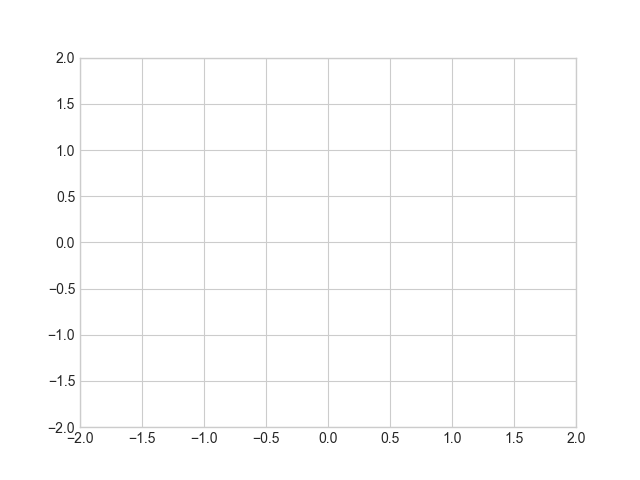

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
point, = ax.plot([], [], 'ro')  # red dot

# Initialization function
def init():
    point.set_data([], [])
    return point,

# Update function for each frame
def update(frame):
    angle = 2 * np.pi * frame / 100
    x = np.cos(angle)
    y = np.sin(angle)
    point.set_data(x, y)
    return point,

# Animate
ani = FuncAnimation(fig, update, frames=100, init_func=init, interval=100, blit=True)

# Show animation
# plt.show()

In [16]:
instance_id = "0b570b8baa5243be821ec380d153de92"
print_debug = False